In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import hdbscan

## Carga y visualización de los datos

Fecha de los documentos asignados: 20250714

In [47]:
volumen = pd.read_csv("https://www.gipuzkoairekia.eus/es/datu-irekien-katalogoa/-/openDataSearcher/download/downloadResource/84ac5875-4728-4df8-aeca-e4f78e5695b9", delimiter=";")
velocidad = pd.read_csv("https://www.gipuzkoairekia.eus/es/datu-irekien-katalogoa/-/openDataSearcher/download/downloadResource/0fa5a8b4-821d-443d-8d76-2db8696dae00", delimiter=";", encoding="latin1").iloc[:, :-1]
estaciones = pd.read_csv("https://www.gipuzkoairekia.eus/es/datu-irekien-katalogoa/-/openDataSearcher/download/downloadResource/d94b5a6f-b707-4dd4-bf08-6fe708afc250", delimiter=";", encoding="latin1", usecols=range(15))

### Preparacion de los datasets velocidad y volumen

Como hay que juntar todos los dataframes en uno solo, procederé a juntarlos por partes, empezando por volumen y velocidad.

Primera visualización de los datasets:

In [48]:
volumen

,Estacion,Fecha,Hora,Carril 1 ligeros,Carril 1 pesados,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados
0,1,14/07/2025,01:00,43,8,0,0,0,0,36,4,16,0,0,0
1,1,14/07/2025,02:00,18,0,0,0,0,0,8,1,6,1,0,0
2,1,14/07/2025,03:00,17,0,0,0,0,0,7,0,2,0,0,0
3,1,14/07/2025,04:00,15,4,0,0,0,0,4,1,4,0,0,0
4,1,14/07/2025,05:00,39,3,0,0,0,0,14,3,9,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12931,9259,20/07/2025,20:00,152,3,0,0,0,0,215,6,0,0,0,0
12932,9259,20/07/2025,21:00,141,7,0,0,0,0,208,10,0,0,0,0
12933,9259,20/07/2025,22:00,104,3,0,0,0,0,196,4,0,0,0,0
12934,9259,20/07/2025,23:00,60,4,0,0,0,0,116,4,0,0,0,0


In [49]:
velocidad

,Fecha,Hora,Sistema,ETD,Detector,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),Velocidad media (km/h),0-6 (m),6-999 (m),Vehículos totales
0,2025-07-14,01:00:00 - 01:30:00,N-634,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",Lento SANTANDER,3,15,1,0,"60,53",19,0,19
1,2025-07-14,01:00:00 - 01:30:00,N-634,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",Lento SAN SEBASTIÁN,3,11,0,0,"56,43",13,1,14
2,2025-07-14,01:00:00 - 01:30:00,N-I,"[N-I] 100-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-...",Central VITORIA-GASTEIZ,0,0,0,0,"0,0",0,0,0
3,2025-07-14,01:00:00 - 01:30:00,N-I,"[N-I] 100-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-...",Lento VITORIA-GASTEIZ,0,12,37,2,"93,33",35,16,51
4,2025-07-14,01:00:00 - 01:30:00,N-I,"[N-I] 100-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-...",Central LASARTE-ORIA,0,0,4,3,"117,14",7,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83069,2025-07-20,24:30:00 - 00:00:00,N-636,"[N-636] 133-ETD BIZKAIA-BERGARA, N-636 pk 29,7...",Lento BIZKAIA,0,9,0,0,65,7,2,9
83070,2025-07-20,24:30:00 - 00:00:00,GI-2132,"[GI-2132] 93-ETD ASTIGARRAGA-ERRENTERIA, GI-21...",Lento ASTIGARRAGA,0,10,4,0,75,11,3,14
83071,2025-07-20,24:30:00 - 00:00:00,GI-2132,"[GI-2132] 93-ETD ASTIGARRAGA-ERRENTERIA, GI-21...",Lento ERRENTERIA,0,9,3,0,"73,75",10,2,12
83072,2025-07-20,24:30:00 - 00:00:00,GI-2632,"[GI-2632] 87-ETD BIZKAIA-BEASAIN, GI-2632 pk 5...",Lento BIZKAIA,1,4,1,0,"64,17",6,0,6


Primero necesito agrupar el dataset de velocidad cada hora en vez de media hora. Para ello cojo la hora inicial de cada fila para que todos los valores se agrupen en su hora respectiva (ejemplo: las horas entre 01:00:00-01:59:59 se quedaran como 01:00 para su agrupacion)

In [50]:
velocidad["Hora"] = velocidad["Hora"].str.split('-').str[0].str[:3] +"00"
velocidad["Hora"] = velocidad["Hora"].astype(str).str.strip()

velocidad["Velocidad media (km/h)"] = velocidad["Velocidad media (km/h)"].str.replace(',', '.')
velocidad["Velocidad media (km/h)"] = pd.to_numeric(velocidad["Velocidad media (km/h)"])



Para hacer la agruación tuve que cambiar el formato de los decimales usando "." y pasar la columna que era de tipo object a numero

In [51]:
df_vel_agrupado = velocidad.groupby(["Fecha", "Hora", "Detector", "ETD"]).agg({
    "0-50 (km/h)": "sum",
    "50-80 (km/h)": "sum",
    "80-120 (km/h)": "sum",
    "120-255 (km/h)": "sum",
    "0-6 (m)": "sum",
    "6-999 (m)": "sum",
    "Vehículos totales": "sum",
    "Velocidad media (km/h)": "mean"
}).reset_index()

Una que tenemos el dataset agrupados por horas tenemos que cambiar las columnas que vayamos a utilizar para la fusión para que coincidan entre ambos datasets

Cambiamos el formato de fecha para que ambos usen el mismo, ademas si nos fijamos en la columna "ETD" nos da mucha información donde encontramos el "ETD code" (del dataset de las estacionees)/ "Estacion" (como viene en el dataset de volumen), ademas de otros datos que usaremos adelante

In [52]:
df_vel_agrupado["Estacion"] = df_vel_agrupado["ETD"].str.split(" ").str[1].str.split("-").str[0]
df_vel_agrupado["Fecha"] = pd.to_datetime(df_vel_agrupado["Fecha"])

In [53]:
df_vel_agrupado

,Fecha,Hora,Detector,ETD,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),0-6 (m),6-999 (m),Vehículos totales,Velocidad media (km/h),Estacion
0,2025-07-14,01:00,Central A GI-20 AÑORGA,[GI-20-10] 34-ETD SAN SEBASTIÁN-A GI-20 AÑORGA...,0,6,5,0,11,0,11,80.750,34
1,2025-07-14,01:00,Central A LA GI-20,"[GI-11] 247-ETD N-I-A LA GI-20, GI-11 pk 0,000...",3,51,40,0,82,12,94,78.630,247
2,2025-07-14,01:00,Central A LA GI-20,"[GI-40] 316-ETD ENLACE HOSPITAL-A LA GI-20, GI...",0,0,5,0,0,5,5,100.000,316
3,2025-07-14,01:00,Central A LA GI-41,"[GI-40] 287-ETD ROTONDA GARBERA-A LA GI-41, GI...",0,2,10,0,12,0,12,94.170,287
4,2025-07-14,01:00,Central A-15,"[GI-41] 302-ETD SAN SEBASTIÁN-A-15, GI-41 pk 0...",0,0,0,5,4,1,5,140.000,302
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41532,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 116-ETD ERRENTERIA AP-8-USURBIL, AP-8,...",0,9,43,3,51,4,55,96.435,116
41533,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 117-ETD ERRENTERIA AP-8-USURBIL, AP-8,...",0,43,63,0,106,0,106,85.805,117
41534,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 249-ETD USURBIL, AP-8-ERRENTERIA AP-8,...",0,0,29,4,32,1,33,104.855,249
41535,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 250-ETD USURBIL, AP-8-ERRENTERIA AP-8,...",0,0,29,4,32,1,33,104.855,250


strip() para quitar los valores en blanco y datetime para que tengan el mismo formato de fecha que en velocidad

In [54]:
volumen["Fecha"] = volumen["Fecha"].str.strip()
volumen["Fecha"] = pd.to_datetime(volumen["Fecha"], format="%d/%m/%Y")

In [55]:
volumen["Estacion"] = volumen["Estacion"].astype(str).str.strip()
volumen["Hora"] = volumen["Hora"].astype(str).str.strip()

In [56]:
df_vel_vol = pd.merge(df_vel_agrupado, volumen, on=["Fecha", "Estacion", "Hora"])
df_vel_vol

,Fecha,Hora,Detector,ETD,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),0-6 (m),6-999 (m),...,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados
0,2025-07-14,01:00,Central A GI-20 AÑORGA,[GI-20-10] 34-ETD SAN SEBASTIÁN-A GI-20 AÑORGA...,0,6,5,0,11,0,...,11,0,0,0,10,2,46,0,3,0
1,2025-07-14,01:00,Central A LA GI-20,"[GI-11] 247-ETD N-I-A LA GI-20, GI-11 pk 0,000...",3,51,40,0,82,12,...,82,12,13,0,33,0,74,4,5,0
2,2025-07-14,01:00,Central A LA GI-20,"[GI-40] 316-ETD ENLACE HOSPITAL-A LA GI-20, GI...",0,0,5,0,0,5,...,0,5,0,0,36,0,2,0,0,0
3,2025-07-14,01:00,Central A LA GI-41,"[GI-40] 287-ETD ROTONDA GARBERA-A LA GI-41, GI...",0,2,10,0,12,0,...,12,0,0,0,88,10,4,0,0,0
4,2025-07-14,01:00,Central A-15,"[GI-41] 302-ETD SAN SEBASTIÁN-A-15, GI-41 pk 0...",0,0,0,5,4,1,...,4,1,0,0,122,14,11,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41532,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 116-ETD ERRENTERIA AP-8-USURBIL, AP-8,...",0,9,43,3,51,4,...,184,8,51,4,95,3,281,13,40,0
41533,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 117-ETD ERRENTERIA AP-8-USURBIL, AP-8,...",0,43,63,0,106,0,...,91,1,106,0,85,3,239,14,20,0
41534,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 249-ETD USURBIL, AP-8-ERRENTERIA AP-8,...",0,0,29,4,32,1,...,117,6,7,0,53,8,64,7,32,1
41535,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 250-ETD USURBIL, AP-8-ERRENTERIA AP-8,...",0,0,29,4,32,1,...,117,6,7,0,219,7,64,7,32,1


### Preparacion del dataframe "estaciones" para la combinacion

In [57]:
estaciones

,System,ETD code,System code,Description,Country code,Country,Municipality code,Municipality,Territory code,Territory,Postal code,GPSX,GPSY,X,Y
0,GI-2132,1,1,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-...",108,España,,,20,Gipuzkoa,,580428.65,4792191.27,-2.008765,43.278246
1,GI-636,3,1,"[GI-636] 3-ETD PASAIA-IRUN, GI-636 pk 7,900, ...",108,España,53,LEZO,20,Gipuzkoa,20100,594584.89,4798000.13,-1.833330,43.328896
2,N-634,11,1,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634...",108,España,30,EIBAR,20,Gipuzkoa,20600,545592.28,4782339.10,-2.438889,43.192449
3,N-I,12,1,"[N-I] 12-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-...",108,España,71,TOLOSA,20,Gipuzkoa,20400,575944.00,4778800.00,-2.065870,43.158142
4,GI-20,16,1,"[GI-20] 16-ETD USURBIL, AP-8-ERRENTERIA,AP-8,...",108,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,583607.00,4795202.00,-1.969142,43.305006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,GI-631,9157,1,"[GI-631] 9157-ETD ZUMARRAGA-ZUMAIA, GI-631 pk...",108,España,27,ZESTOA,20,Gipuzkoa,20740,559996.77,4788856.73,-2.260914,43.250126
81,GI-2632,9159,1,"[GI-2632] 9159-ETD BEASAIN-BIZKAIA, GI-2632 p...",108,España,77,URRETXU,20,Gipuzkoa,20700,553008.18,4770764.28,-2.348733,43.087742
82,GI-627,9211,1,"[GI-627] 9211-ETD ARABA-EIBAR, GI-627 pk 51,4...",108,España,74,BERGARA,20,Gipuzkoa,20570,547942.85,4779948.64,-2.410168,43.170779
83,GI-2630,9259,1,"[GI-2630] 9259-ETD URRETXU-BERGARA, GI-2630 p...",108,España,51,LEGAZPI,20,Gipuzkoa,20230,554510.32,4769098.80,-2.330442,43.072638


la columna "ETD" proveniente originalmente del dtaframe de velocidad, observando la parte entre "[]" equivale a los valores de la columna "System" en el dataframe de estaciones

In [58]:
df_vel_vol["System"] = (df_vel_vol["ETD"].str.split().str[0].str[1:-1]).astype(str).str.strip()
estaciones["System"] = estaciones["System"].astype(str).str.strip()

In [59]:
estaciones = estaciones.rename(columns={"ETD code": "Estacion"})
estaciones["Estacion"] = estaciones["Estacion"].astype(str).str.strip()

In [60]:
df_complete = pd.merge(df_vel_vol, estaciones, on=["System", "Estacion"])
df_complete

,Fecha,Hora,Detector,ETD,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),0-6 (m),6-999 (m),...,Country,Municipality code,Municipality,Territory code,Territory,Postal code,GPSX,GPSY,X,Y
0,2025-07-14,01:00,Central A GI-20 AÑORGA,[GI-20-10] 34-ETD SAN SEBASTIÁN-A GI-20 AÑORGA...,0,6,5,0,11,0,...,España,,,20,Gipuzkoa,,581046.27,4794501.34,-2.000813,43.298978
1,2025-07-14,01:00,Central A LA GI-20,"[GI-11] 247-ETD N-I-A LA GI-20, GI-11 pk 0,000...",3,51,40,0,82,12,...,España,,,20,Gipuzkoa,,579563.00,4793248.00,-2.019279,43.287852
2,2025-07-14,01:00,Central A LA GI-20,"[GI-40] 316-ETD ENLACE HOSPITAL-A LA GI-20, GI...",0,0,5,0,0,5,...,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,583479.00,4794342.00,-1.970850,43.297277
3,2025-07-14,01:00,Central A LA GI-41,"[GI-40] 287-ETD ROTONDA GARBERA-A LA GI-41, GI...",0,2,10,0,12,0,...,España,,,20,Gipuzkoa,,585400.78,4795380.65,-1.947001,43.306412
4,2025-07-14,01:00,Central A-15,"[GI-41] 302-ETD SAN SEBASTIÁN-A-15, GI-41 pk 0...",0,0,0,5,4,1,...,España,,,20,Gipuzkoa,,584610.70,4793770.74,-1.956989,43.292008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41532,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 116-ETD ERRENTERIA AP-8-USURBIL, AP-8,...",0,9,43,3,51,4,...,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,581675.00,4794313.00,-1.993091,43.297214
41533,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 117-ETD ERRENTERIA AP-8-USURBIL, AP-8,...",0,43,63,0,106,0,...,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,584777.00,4796279.00,-1.954552,43.314571
41534,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 249-ETD USURBIL, AP-8-ERRENTERIA AP-8,...",0,0,29,4,32,1,...,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,579205.64,4793190.16,-2.023691,43.287369
41535,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 250-ETD USURBIL, AP-8-ERRENTERIA AP-8,...",0,0,29,4,32,1,...,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,579880.43,4793998.79,-2.015258,43.294578


## Preprocesamiento

In [61]:
df_complete.columns

Index(['Fecha', 'Hora', 'Detector', 'ETD', '0-50 (km/h)', '50-80 (km/h)',
       '80-120 (km/h)', '120-255 (km/h)', '0-6 (m)', '6-999 (m)',
       'Vehículos totales', 'Velocidad media (km/h)', 'Estacion',
       'Carril 1 ligeros ', 'Carril 1 pesados', 'Carril 2 ligeros ',
       'Carril 2 pesados', 'Carril 3 ligeros ', 'Carril 3 pesados',
       'Carril 4 ligeros ', 'Carril 4 pesados', 'Carril 5 ligeros ',
       'Carril 5 pesados', 'Carril 6 ligeros ', 'Carril 6 pesados', 'System',
       'System code', 'Description', 'Country code', 'Country',
       'Municipality code', 'Municipality', 'Territory code', 'Territory',
       'Postal code', 'GPSX', 'GPSY', 'X', 'Y'],
      dtype='object')

En esta parte quito las columnas que a simple viste no aportan valor, ya sea porque sean claves primarias que no aportan valor al dataset, como columnas donde todos los valores ta sea el mismo como es el caso de country o territory. La columna description la quito ya que es lo mimsmo que el ETD

In [62]:
df_complete = df_complete.drop(columns=["System code", "Territory code", "Country", "Country code", "Territory", "Description", "Municipality code"])

In [63]:
df_complete

,Fecha,Hora,Detector,ETD,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),0-6 (m),6-999 (m),...,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados,System,Municipality,Postal code,GPSX,GPSY,X,Y
0,2025-07-14,01:00,Central A GI-20 AÑORGA,[GI-20-10] 34-ETD SAN SEBASTIÁN-A GI-20 AÑORGA...,0,6,5,0,11,0,...,0,3,0,GI-20-10,,,581046.27,4794501.34,-2.000813,43.298978
1,2025-07-14,01:00,Central A LA GI-20,"[GI-11] 247-ETD N-I-A LA GI-20, GI-11 pk 0,000...",3,51,40,0,82,12,...,4,5,0,GI-11,,,579563.00,4793248.00,-2.019279,43.287852
2,2025-07-14,01:00,Central A LA GI-20,"[GI-40] 316-ETD ENLACE HOSPITAL-A LA GI-20, GI...",0,0,5,0,0,5,...,0,0,0,GI-40,DONOSTIA-SAN SEBASTIAN,0,583479.00,4794342.00,-1.970850,43.297277
3,2025-07-14,01:00,Central A LA GI-41,"[GI-40] 287-ETD ROTONDA GARBERA-A LA GI-41, GI...",0,2,10,0,12,0,...,0,0,0,GI-40,,,585400.78,4795380.65,-1.947001,43.306412
4,2025-07-14,01:00,Central A-15,"[GI-41] 302-ETD SAN SEBASTIÁN-A-15, GI-41 pk 0...",0,0,0,5,4,1,...,0,0,0,GI-41,,,584610.70,4793770.74,-1.956989,43.292008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41532,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 116-ETD ERRENTERIA AP-8-USURBIL, AP-8,...",0,9,43,3,51,4,...,13,40,0,GI-20,DONOSTIA-SAN SEBASTIAN,0,581675.00,4794313.00,-1.993091,43.297214
41533,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 117-ETD ERRENTERIA AP-8-USURBIL, AP-8,...",0,43,63,0,106,0,...,14,20,0,GI-20,DONOSTIA-SAN SEBASTIAN,0,584777.00,4796279.00,-1.954552,43.314571
41534,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 249-ETD USURBIL, AP-8-ERRENTERIA AP-8,...",0,0,29,4,32,1,...,7,32,1,GI-20,DONOSTIA-SAN SEBASTIAN,0,579205.64,4793190.16,-2.023691,43.287369
41535,2025-07-20,24:00,"Rápido USURBIL, AP-8","[GI-20] 250-ETD USURBIL, AP-8-ERRENTERIA AP-8,...",0,0,29,4,32,1,...,7,32,1,GI-20,DONOSTIA-SAN SEBASTIAN,0,579880.43,4793998.79,-2.015258,43.294578


### Reduccion de dimensionalidad con PCA

In [64]:
X = df_complete.drop(columns=["Fecha", "Hora", "Detector", "ETD", "Estacion", "Municipality", "System", "Postal code"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_test = PCA().fit(X_scaled)
varianza_acum = np.cumsum(pca_test.explained_variance_ratio_)
varianza_acum

array([0.35360734, 0.5077299 , 0.65245917, 0.73698123, 0.78735717,
       0.82696796, 0.85541193, 0.87725382, 0.89782737, 0.91388005,
       0.9289734 , 0.94305331, 0.95548909, 0.96556674, 0.9749604 ,
       0.98296282, 0.98846154, 0.99306487, 0.99714402, 0.99999985,
       0.99999996, 1.        , 1.        , 1.        ])

Segun la varianza acumulada me quedare con 7 componentes ( 85% de los datos)

In [65]:
pca = PCA(n_components=7) 
X_pca = pca.fit_transform(X_scaled)

Previsualizacion de los datos antes de agruparlos

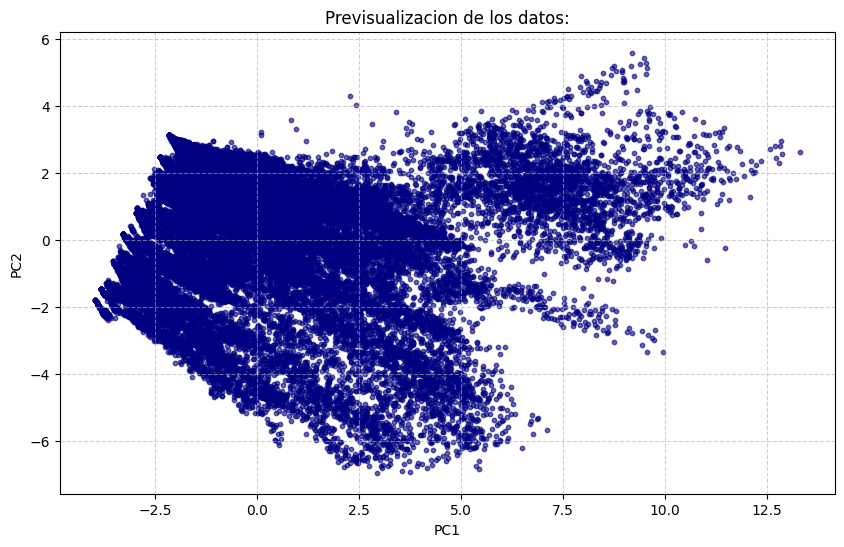

In [66]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=10, c='navy')
plt.title("Previsualizacion de los datos:")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Eleccion de Algoritmo

El algoritmo que elegi para este caso de prueba sera hdbscan, el motivo fue simplemente que en clase vimos que fue el que mejor funcionaba (a priori) y por ello decidi trabajar con el

In [67]:
clusterer = hdbscan.HDBSCAN(min_cluster_size= 15, min_samples=5,gen_min_span_tree=True)
clusterer.fit(X_pca)

,min_cluster_size,15
,min_samples,5
,cluster_selection_epsilon,0.0
,cluster_selection_persistence,0.0
,max_cluster_size,0
,metric,'euclidean'
,alpha,1.0
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)


## Resultados

In [68]:
# Añadimos la columna de cluster al dataframe original
df_complete["Cluster"] = clusterer.labels_

print("Conteo por clúster:")
print(df_complete["Cluster"].value_counts())

Conteo por clúster:
Cluster
-1      19173
 195      891
 207      618
 65       471
 324      336
        ...  
 189       15
 137       15
 125       15
 122       15
 79        15
Name: count, Length: 369, dtype: int64


Como se puede observar se detecta mucha cantidad de datos como valores atipicos

Ahora muestro una visualizacion de como queda una vez se ha producido los clusters

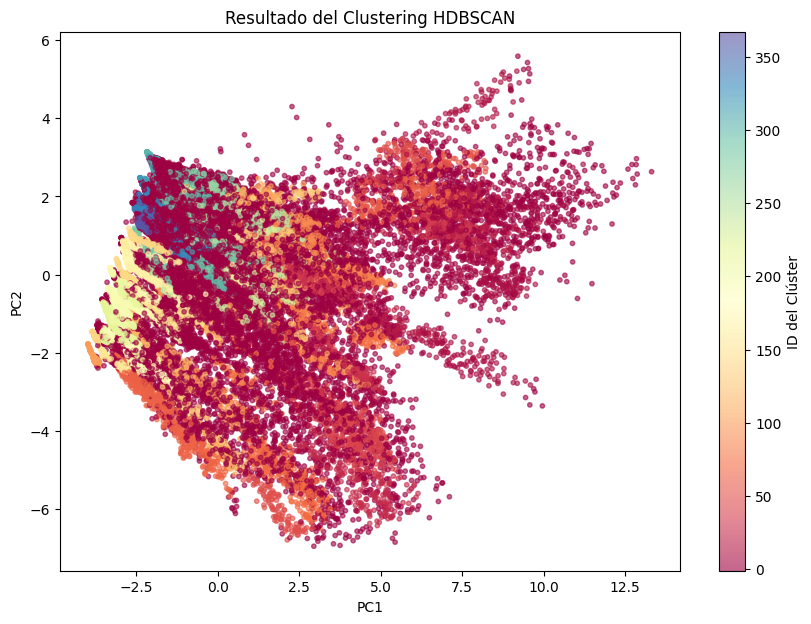

In [69]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=df_complete["Cluster"], 
                      cmap="Spectral", 
                      s=10,
                      alpha=0.6)

plt.colorbar(scatter, label='ID del Clúster')
plt.title('Resultado del Clustering HDBSCAN')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

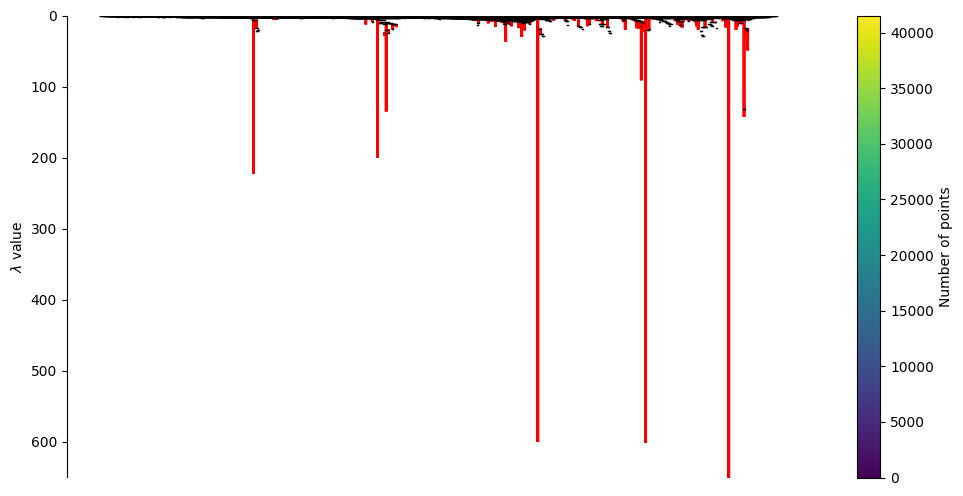

In [70]:
import seaborn as sns
plt.figure(figsize=(12, 6))
clusterer.condensed_tree_.plot(select_clusters=True, 
                               selection_palette=sns.color_palette())
plt.show()